# Model Validation
Goes beyond standard ML metrics (AUC alone) to the checks a credit-risk model validation / model risk management (MRM) team actually runs before sign-off, applied to both models built so far:

| Metric type | Metric | Benchmark |
|---|---|---|
| Discrimination | Kolmogorov-Smirnov (KS) | KS > 40% |
| Rank ordering | Gini = 2*AUC - 1, + monotonicity check | higher risk must map to strictly lower score/higher PD, bucket-by-bucket |
| Calibration | Brier score & Expected/Actual ratio | E/A close to 1.0 in every decile |
| Stability | Population Stability Index (PSI), Dev vs. Validation | PSI < 0.1 stable, 0.1-0.25 moderate shift (monitor), > 0.25 significant shift (investigate/rebuild) |

Standalone notebook: reloads raw data, re-derives the engineered features, and rebuilds both models (`scorecard.ipynb`'s WoE/PDO scorecard and `gbm_model.ipynb`'s winning SMOTE+LightGBM+Isotonic pipeline) so it can run independently.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from optbinning import BinningProcess
import lightgbm as lgb
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import roc_auc_score, brier_score_loss

pd.set_option('display.max_columns', 100)

DEV_PATH = 'Dev_data_to_be_shared.csv'
VAL_PATH = 'validation_data_to_be_shared.csv'

dev = pd.read_csv(DEV_PATH)
val = pd.read_csv(VAL_PATH)
print('dev:', dev.shape, '| val:', val.shape)

dev: (96806, 1216) | val: (41792, 1215)


## Recreate domain-engineered features and candidate columns
Identical logic to `feature_engineering.ipynb`, `scorecard.ipynb`, `gbm_model.ipynb`.

In [2]:
onus_cols = [c for c in dev.columns if c.startswith('onus_attribute')]
txn_cols = [c for c in dev.columns if c.startswith('transaction_attribute')]
enq_cols = [c for c in dev.columns if c.startswith('bureau_enquiry')]
bureau_cols = [c for c in dev.columns if c.startswith('bureau_') and c not in enq_cols]

util_cols = ['onus_attribute_2', 'onus_attribute_17', 'onus_attribute_20', 'onus_attribute_23']
block1_cols = [f'bureau_enquiry_{i}' for i in range(1, 11)]
block5_cols = [f'bureau_enquiry_{i}' for i in range(41, 51)]

num_cols_all = dev.select_dtypes(include=[np.number]).columns.drop(['bad_flag'], errors='ignore')
corr_with_target = dev[num_cols_all].corrwith(dev['bad_flag'])

Xc = dev[txn_cols].fillna(0)
corr_txn = Xc.corr().fillna(0).values
np.fill_diagonal(corr_txn, 1.0)
dist = 1 - np.abs(corr_txn)
dist[dist < 0] = 0
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method='average')
cluster_labels = fcluster(Z, 14, criterion='maxclust')
cluster_map = pd.Series(cluster_labels, index=txn_cols)
nonzero_frac = (Xc != 0).mean()
corr_target_txn = corr_with_target.reindex(txn_cols)
cluster_stats = pd.DataFrame({
    'n_cols': cluster_map.value_counts(),
    'mean_nonzero_frac': nonzero_frac.groupby(cluster_map).mean(),
    'mean_abs_corr_target': corr_target_txn.abs().groupby(cluster_map).mean(),
})
spend_cluster = cluster_stats['n_cols'].idxmax()
sizable = cluster_stats[cluster_stats['n_cols'] >= 10]
cash_cluster = sizable['mean_nonzero_frac'].idxmin()
highrisk_cluster = sizable.drop(index=[spend_cluster, cash_cluster], errors='ignore')['mean_abs_corr_target'].idxmax()
spend_cols = cluster_map[cluster_map == spend_cluster].index.tolist()
cash_cols = cluster_map[cluster_map == cash_cluster].index.tolist()
highrisk_cols = cluster_map[cluster_map == highrisk_cluster].index.tolist()

count_like_bureau = [c for c in bureau_cols if dev[c].nunique() <= 15 and dev[c].min() >= 0]
delinquency_cols = corr_with_target.reindex(count_like_bureau).abs().sort_values(ascending=False).head(20).index.tolist()


def add_engineered_features(df):
    df = df.copy()
    df['internal_utilization'] = df['onus_attribute_2']
    df['internal_utilization_avg4'] = df[util_cols].mean(axis=1)
    df['limit_stress_persistence'] = (df[util_cols] >= 0.8).sum(axis=1)

    df['cash_amount_proxy'] = df[cash_cols].sum(axis=1)
    df['spend_amount_proxy'] = df[spend_cols].sum(axis=1)
    df['highrisk_merchant_proxy'] = df[highrisk_cols].sum(axis=1)
    df['total_txn_activity'] = df[txn_cols].sum(axis=1)
    df['cash_vs_spend_ratio'] = df['cash_amount_proxy'] / (df['cash_amount_proxy'] + df['spend_amount_proxy'] + 1)
    df['highrisk_merchant_share'] = df['highrisk_merchant_proxy'] / (df['total_txn_activity'].abs() + 1)
    df['merchant_breadth'] = (df[txn_cols] != 0).sum(axis=1)

    df['external_utilization'] = df['bureau_433']
    df['utilization_gap'] = df['internal_utilization'] - df['external_utilization']
    df['delinquency_flag_count'] = (df[delinquency_cols] > 0).sum(axis=1)
    df['worst_bureau_status'] = df[delinquency_cols].max(axis=1)

    df['enquiries_recent'] = df[block1_cols].sum(axis=1)
    df['enquiries_longterm'] = df[block5_cols].sum(axis=1)
    df['credit_seeking_intensity'] = df['enquiries_recent'] / (df['enquiries_longterm'] + 1)
    return df


engineered_cols = ['internal_utilization', 'internal_utilization_avg4', 'limit_stress_persistence',
                   'cash_vs_spend_ratio', 'highrisk_merchant_share', 'merchant_breadth', 'total_txn_activity',
                   'external_utilization', 'utilization_gap', 'delinquency_flag_count', 'worst_bureau_status',
                   'enquiries_recent', 'enquiries_longterm', 'credit_seeking_intensity']

dev = add_engineered_features(dev)
val = add_engineered_features(val)

candidate_cols_raw = onus_cols + txn_cols + bureau_cols + enq_cols + engineered_cols
nunique_dropna = dev[candidate_cols_raw].nunique(dropna=True)
dropped_degenerate = nunique_dropna[nunique_dropna <= 1].index.tolist()
candidate_cols = [c for c in candidate_cols_raw if c not in dropped_degenerate]
print('candidate features:', len(candidate_cols))

candidate features: 1172


## Rebuild Model 1: WoE / IV Scorecard
Same pipeline as `scorecard.ipynb`: monotonic WoE binning, IV filter (0.02-0.5), redundancy pruning + sign-consistent Logistic Regression, PDO scaling.

In [3]:
X_all = dev[candidate_cols]
y_all = dev['bad_flag']
sc_X_train, sc_X_test, sc_y_train, sc_y_test = train_test_split(X_all, y_all, test_size=0.25, stratify=y_all, random_state=42)

bp = BinningProcess(variable_names=candidate_cols, selection_criteria={'iv': {'min': 0.02, 'max': 0.5}}, n_jobs=4)
bp.fit(sc_X_train, sc_y_train)
iv_summary = bp.summary().set_index('name')
selected_vars = bp.get_support(names=True)

Xw_train = bp.transform(sc_X_train, metric='woe')[selected_vars]
Xw_test = bp.transform(sc_X_test, metric='woe')[selected_vars]

ordered = iv_summary.loc[selected_vars, 'iv'].sort_values(ascending=False).index.tolist()
pruned_vars = []
for c in ordered:
    if not pruned_vars:
        pruned_vars.append(c)
        continue
    if Xw_train[pruned_vars].corrwith(Xw_train[c]).abs().max() < 0.6:
        pruned_vars.append(c)
    if len(pruned_vars) >= 20:
        break

sc_final_vars = list(pruned_vars)
while True:
    sc_lr = LogisticRegression(solver='lbfgs', max_iter=1000)
    sc_lr.fit(Xw_train[sc_final_vars], sc_y_train)
    coefs = dict(zip(sc_final_vars, sc_lr.coef_[0]))
    wrong_sign = [v for v, c in coefs.items() if c > 0]
    if not wrong_sign:
        break
    sc_final_vars.remove(max(wrong_sign, key=lambda v: coefs[v]))

print('scorecard final variables:', len(sc_final_vars))

PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)
sc_intercept = sc_lr.intercept_[0]

def sc_score(Xw_sel):
    log_odds_bad = sc_intercept + (Xw_sel[sc_final_vars].values * sc_lr.coef_[0]).sum(axis=1)
    return OFFSET - FACTOR * log_odds_bad

sc_p_test = sc_lr.predict_proba(Xw_test[sc_final_vars])[:, 1]
sc_score_test = sc_score(Xw_test)

X_val_sc = val[candidate_cols]
Xw_val = bp.transform(X_val_sc, metric='woe')[sc_final_vars]
sc_p_val = sc_lr.predict_proba(Xw_val[sc_final_vars])[:, 1]
sc_score_val = sc_score(Xw_val)

print('scorecard test AUC:', roc_auc_score(sc_y_test, sc_p_test))

scorecard final variables: 16


scorecard test AUC: 0.8050468880767805


## Rebuild Model 2: SMOTE + LightGBM + Isotonic calibration
The winning combination found in `gbm_model.ipynb`'s comparison (class weights vs. SMOTE vs. ADASYN; Platt vs. Isotonic) - rebuilt directly here rather than re-running the full comparison.

In [4]:
gb_X_train, gb_X_temp, gb_y_train, gb_y_temp = train_test_split(X_all, y_all, test_size=0.40, stratify=y_all, random_state=42)
gb_X_calib, gb_X_test, gb_y_calib, gb_y_test = train_test_split(gb_X_temp, gb_y_temp, test_size=0.625, stratify=gb_y_temp, random_state=42)

median = gb_X_train.median()
gb_X_train_imp = gb_X_train.fillna(median)
gb_X_calib_imp = gb_X_calib.fillna(median)
gb_X_test_imp = gb_X_test.fillna(median)

X_res, y_res = SMOTE(random_state=42, k_neighbors=5).fit_resample(gb_X_train_imp, gb_y_train)

gb_base = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.03, num_leaves=31, max_depth=-1,
                              subsample=0.8, colsample_bytree=0.8, metric='auc', random_state=42, verbosity=-1)
gb_base.fit(X_res, y_res, eval_set=[(gb_X_calib_imp, gb_y_calib)],
            callbacks=[lgb.early_stopping(100, first_metric_only=True, verbose=False)])

gb_isotonic = CalibratedClassifierCV(FrozenEstimator(gb_base), method='isotonic')
gb_isotonic.fit(gb_X_calib_imp, gb_y_calib)

gb_p_test = gb_isotonic.predict_proba(gb_X_test_imp)[:, 1]

X_val_gb = val[candidate_cols].fillna(median)
gb_p_val = gb_isotonic.predict_proba(X_val_gb)[:, 1]

print('GBM (SMOTE+Isotonic) test AUC:', roc_auc_score(gb_y_test, gb_p_test))

GBM (SMOTE+Isotonic) test AUC: 0.8342882266161122


## Validation metric functions

In [5]:
def ks_stat(y_true, y_score):
    order = np.argsort(y_score)
    y_true_sorted = np.asarray(y_true)[order]
    n_bad = y_true_sorted.sum()
    n_good = len(y_true_sorted) - n_bad
    cum_bad = np.cumsum(y_true_sorted) / n_bad
    cum_good = np.cumsum(1 - y_true_sorted) / n_good
    return np.max(np.abs(cum_bad - cum_good))


def rank_order_table(y_true, y_score, higher_score_is_safer, n_bins=10):
    """Bucket by score/probability into deciles, ordered safest -> riskiest, and report observed bad rate per bucket."""
    df = pd.DataFrame({'y': np.asarray(y_true), 'score': np.asarray(y_score)})
    df['bucket'] = pd.qcut(df['score'], n_bins, duplicates='drop')
    table = df.groupby('bucket', observed=True).agg(n=('y', 'size'), bad_rate=('y', 'mean'), avg_score=('score', 'mean'))
    # sort safest-first: if higher score = safer, that's descending score; if higher score = riskier, that's ascending score
    table = table.sort_values('avg_score', ascending=not higher_score_is_safer)
    bad_rates = table['bad_rate'].values
    # once ordered safest -> riskiest, bad_rate must be non-decreasing for the score to be strictly rank-ordering risk
    is_monotonic = bool(np.all(np.diff(bad_rates) >= -1e-12))
    return table, is_monotonic


def expected_actual_table(y_true, p_pred, n_bins=10):
    df = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(p_pred)})
    df['bucket'] = pd.qcut(df['p'], n_bins, duplicates='drop')
    table = df.groupby('bucket', observed=True).agg(n=('y', 'size'), expected=('p', 'mean'), actual=('y', 'mean'))
    table['EA_ratio'] = table['expected'] / table['actual'].replace(0, np.nan)
    return table


def psi(reference, current, n_bins=10):
    """PSI of `current` vs `reference` distribution, binned on reference deciles."""
    reference = np.asarray(reference)
    current = np.asarray(current)
    quantiles = np.unique(np.quantile(reference, np.linspace(0, 1, n_bins + 1)))
    quantiles[0], quantiles[-1] = -np.inf, np.inf
    ref_counts, _ = np.histogram(reference, bins=quantiles)
    cur_counts, _ = np.histogram(current, bins=quantiles)
    ref_pct = np.clip(ref_counts / ref_counts.sum(), 1e-6, None)
    cur_pct = np.clip(cur_counts / cur_counts.sum(), 1e-6, None)
    contrib = (cur_pct - ref_pct) * np.log(cur_pct / ref_pct)
    bins_df = pd.DataFrame({
        'bin': [f'({quantiles[i]:.3g}, {quantiles[i+1]:.3g}]' for i in range(len(quantiles) - 1)],
        'reference_pct': ref_pct, 'current_pct': cur_pct, 'psi_contribution': contrib,
    })
    return contrib.sum(), bins_df


def psi_flag(value):
    if value < 0.1:
        return 'stable'
    elif value < 0.25:
        return 'moderate shift - monitor'
    else:
        return 'significant shift - investigate/rebuild'

print('metric functions ready')

metric functions ready


## 1. Discrimination (KS) and Rank Ordering (Gini / AUC + monotonicity)

In [6]:
sc_ks = ks_stat(sc_y_test, sc_p_test)
gb_ks = ks_stat(gb_y_test, gb_p_test)

sc_auc = roc_auc_score(sc_y_test, sc_p_test)
gb_auc = roc_auc_score(gb_y_test, gb_p_test)

sc_rank_table, sc_monotonic = rank_order_table(sc_y_test, sc_score_test, higher_score_is_safer=True)
gb_rank_table, gb_monotonic = rank_order_table(gb_y_test, gb_p_test, higher_score_is_safer=False)

print('=== Scorecard ===')
print(f'KS = {sc_ks:.4f} ({sc_ks*100:.1f}%)  ->  {"PASS" if sc_ks > 0.40 else "FAIL"} (target > 40%)')
print(f'AUC = {sc_auc:.4f}  Gini = {2*sc_auc-1:.4f}')
print(f'Rank-order monotonic (score deciles, safest->riskiest): {sc_monotonic}')
print()
print('=== GBM (SMOTE + Isotonic) ===')
print(f'KS = {gb_ks:.4f} ({gb_ks*100:.1f}%)  ->  {"PASS" if gb_ks > 0.40 else "FAIL"} (target > 40%)')
print(f'AUC = {gb_auc:.4f}  Gini = {2*gb_auc-1:.4f}')
print(f'Rank-order monotonic (probability deciles, safest->riskiest): {gb_monotonic}')

=== Scorecard ===
KS = 0.4597 (46.0%)  ->  PASS (target > 40%)
AUC = 0.8050  Gini = 0.6101
Rank-order monotonic (score deciles, safest->riskiest): True

=== GBM (SMOTE + Isotonic) ===
KS = 0.5296 (53.0%)  ->  PASS (target > 40%)
AUC = 0.8343  Gini = 0.6686
Rank-order monotonic (probability deciles, safest->riskiest): True


In [7]:
print('Scorecard rank-order table (score deciles, safest first):')
sc_rank_table

Scorecard rank-order table (score deciles, safest first):


,n,bad_rate,avg_score
bucket,,,
"(682.755, 747.194]",2421,0.000000,698.731228
"(663.947, 682.755]",2420,0.001653,672.763824
"(650.414, 663.947]",2420,0.002479,656.888768
"(638.733, 650.414]",2420,0.002893,644.433020
"(628.617, 638.733]",2420,0.005785,633.672916
"(618.895, 628.617]",2420,0.010331,623.877487
"(608.388, 618.895]",2420,0.014876,613.699393
"(597.211, 608.388]",2420,0.015289,602.896926
"(583.226, 597.211]",2420,0.024793,590.846025


In [8]:
print('GBM rank-order table (probability deciles, safest first):')
gb_rank_table

GBM rank-order table (probability deciles, safest first):


,n,bad_rate,avg_score
bucket,,,
"(-0.001, 0.00139]",3388,0.000295,0.000996
"(0.00139, 0.00205]",2542,0.000393,0.001891
"(0.00205, 0.00255]",3301,0.003332,0.002546
"(0.00255, 0.00277]",1234,0.004052,0.002774
"(0.00277, 0.00565]",1876,0.004797,0.004510
"(0.00565, 0.0089]",2390,0.007531,0.008437
"(0.0089, 0.0131]",2723,0.009548,0.013055
"(0.0131, 0.0229]",2327,0.016330,0.020466
"(0.0229, 0.0312]",2170,0.032258,0.029570


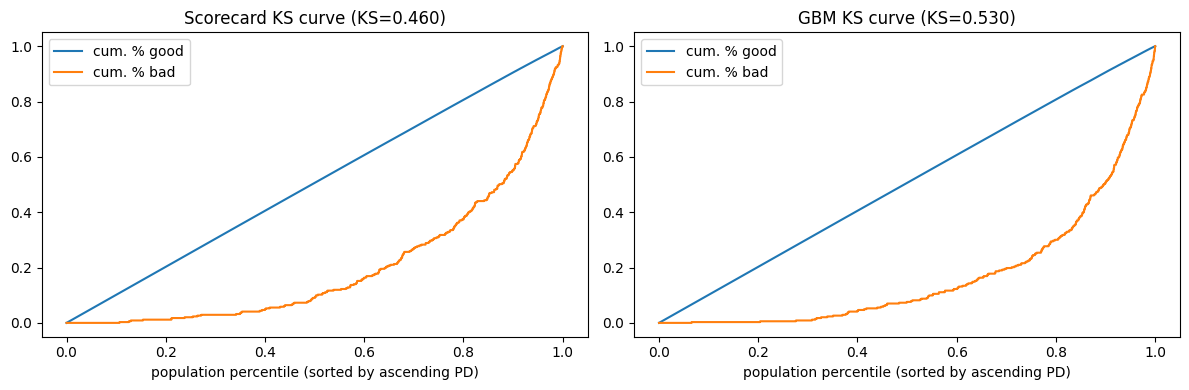

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, y_true, p) in zip(axes, [('Scorecard', sc_y_test, sc_p_test), ('GBM', gb_y_test, gb_p_test)]):
    order = np.argsort(p)
    y_sorted = np.asarray(y_true)[order]
    n_bad, n_good = y_sorted.sum(), len(y_sorted) - y_sorted.sum()
    cum_bad = np.cumsum(y_sorted) / n_bad
    cum_good = np.cumsum(1 - y_sorted) / n_good
    pct = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    ax.plot(pct, cum_good, label='cum. % good')
    ax.plot(pct, cum_bad, label='cum. % bad')
    ax.set_title(f'{name} KS curve (KS={np.max(np.abs(cum_bad-cum_good)):.3f})')
    ax.set_xlabel('population percentile (sorted by ascending PD)')
    ax.legend()
plt.tight_layout()
plt.show()

## 2. Calibration: Brier Score & Expected/Actual Ratio

In [10]:
sc_brier = brier_score_loss(sc_y_test, sc_p_test)
gb_brier = brier_score_loss(gb_y_test, gb_p_test)

sc_ea = expected_actual_table(sc_y_test, sc_p_test)
gb_ea = expected_actual_table(gb_y_test, gb_p_test)

sc_overall_ea = sc_p_test.mean() / sc_y_test.mean()
gb_overall_ea = gb_p_test.mean() / gb_y_test.mean()

print('=== Scorecard ===')
print(f'Brier score = {sc_brier:.5f}')
print(f'Overall E/A ratio = {sc_overall_ea:.3f}  (expected mean PD={sc_p_test.mean():.4f}, actual bad rate={sc_y_test.mean():.4f})')
print()
print('=== GBM ===')
print(f'Brier score = {gb_brier:.5f}')
print(f'Overall E/A ratio = {gb_overall_ea:.3f}  (expected mean PD={gb_p_test.mean():.4f}, actual bad rate={gb_y_test.mean():.4f})')

=== Scorecard ===
Brier score = 0.01366
Overall E/A ratio = 0.997  (expected mean PD=0.0141, actual bad rate=0.0142)

=== GBM ===
Brier score = 0.01351
Overall E/A ratio = 0.988  (expected mean PD=0.0140, actual bad rate=0.0142)


In [11]:
print('Scorecard Expected/Actual by decile:')
sc_ea

Scorecard Expected/Actual by decile:


,n,expected,actual,EA_ratio
bucket,,,,
"(-0.000878, 0.00113]",2421,0.000707,0.000000,NaN
"(0.00113, 0.00218]",2420,0.001632,0.001653,0.987080
"(0.00218, 0.00347]",2420,0.002802,0.002479,1.130147
"(0.00347, 0.0052]",2420,0.004298,0.002893,1.485919
"(0.0052, 0.00736]",2420,0.006219,0.005785,1.074943
"(0.00736, 0.0103]",2420,0.008708,0.010331,0.842963
"(0.0103, 0.0147]",2420,0.012354,0.014876,0.830452
"(0.0147, 0.0216]",2420,0.017873,0.015289,1.168973
"(0.0216, 0.0345]",2420,0.026971,0.024793,1.087815


In [12]:
print('GBM Expected/Actual by decile:')
gb_ea

GBM Expected/Actual by decile:


,n,expected,actual,EA_ratio
bucket,,,,
"(-0.001, 0.00139]",3388,0.000996,0.000295,3.373359
"(0.00139, 0.00205]",2542,0.001891,0.000393,4.806749
"(0.00205, 0.00255]",3301,0.002546,0.003332,0.763922
"(0.00255, 0.00277]",1234,0.002774,0.004052,0.684605
"(0.00277, 0.00565]",1876,0.004510,0.004797,0.940006
"(0.00565, 0.0089]",2390,0.008437,0.007531,1.120232
"(0.0089, 0.0131]",2723,0.013055,0.009548,1.367275
"(0.0131, 0.0229]",2327,0.020466,0.016330,1.253281
"(0.0229, 0.0312]",2170,0.029570,0.032258,0.916681


## 3. Stability: Population Stability Index (Dev test-set vs. Validation)
PSI compares the scored-population distribution the model was validated on (dev `test` split, as "Expected"/reference) against the population it is actually being asked to score (`validation_data_to_be_shared.csv`, as "Actual"/current), using decile bins fixed on the reference distribution. This is the standard vintage/population-drift check before deploying a model.

In [13]:
sc_psi_value, sc_psi_table = psi(sc_score_test, sc_score_val)
gb_psi_value, gb_psi_table = psi(gb_p_test, gb_p_val)

print(f'Scorecard PSI (score, dev test vs. validation) = {sc_psi_value:.4f}  -> {psi_flag(sc_psi_value)}')
print(f'GBM PSI (probability, dev test vs. validation)  = {gb_psi_value:.4f}  -> {psi_flag(gb_psi_value)}')

Scorecard PSI (score, dev test vs. validation) = 0.0006  -> stable
GBM PSI (probability, dev test vs. validation)  = 0.0003  -> stable


In [14]:
print('Scorecard PSI by bin:')
sc_psi_table

Scorecard PSI by bin:


,bin,reference_pct,current_pct,psi_contribution
0,"(-inf, 583]",0.100033,0.098918,1.248898e-05
1,"(583, 597]",0.099992,0.099588,1.629918e-06
2,"(597, 608]",0.099992,0.099971,4.182737e-09
3,"(608, 619]",0.099992,0.100378,1.489730e-06
4,"(619, 629]",0.099992,0.096741,1.074374e-04
5,"(629, 639]",0.099992,0.097650,5.548142e-05
6,"(639, 650]",0.099992,0.101670,2.794009e-05
7,"(650, 664]",0.099992,0.097770,4.992604e-05
8,"(664, 683]",0.099992,0.105235,2.680204e-04
9,"(683, inf]",0.100033,0.102077,4.134045e-05


In [15]:
print('GBM PSI by bin:')
gb_psi_table

GBM PSI by bin:


,bin,reference_pct,current_pct,psi_contribution
0,"(-inf, 0.00139]",0.089579,0.091955,6.220092e-05
1,"(0.00139, 0.00205]",0.091439,0.091573,1.957182e-07
2,"(0.00205, 0.00255]",0.064127,0.065252,1.955789e-05
3,"(0.00255, 0.00277]",0.136270,0.138974,5.313931e-05
4,"(0.00277, 0.00565]",0.092637,0.092673,1.419541e-08
5,"(0.00565, 0.0089]",0.057516,0.058360,1.231083e-05
6,"(0.0089, 0.0131]",0.077142,0.075756,2.513782e-05
7,"(0.0131, 0.0229]",0.161970,0.159696,3.216511e-05
8,"(0.0229, 0.0312]",0.123833,0.120765,7.696830e-05
9,"(0.0312, inf]",0.105487,0.104996,2.290539e-06


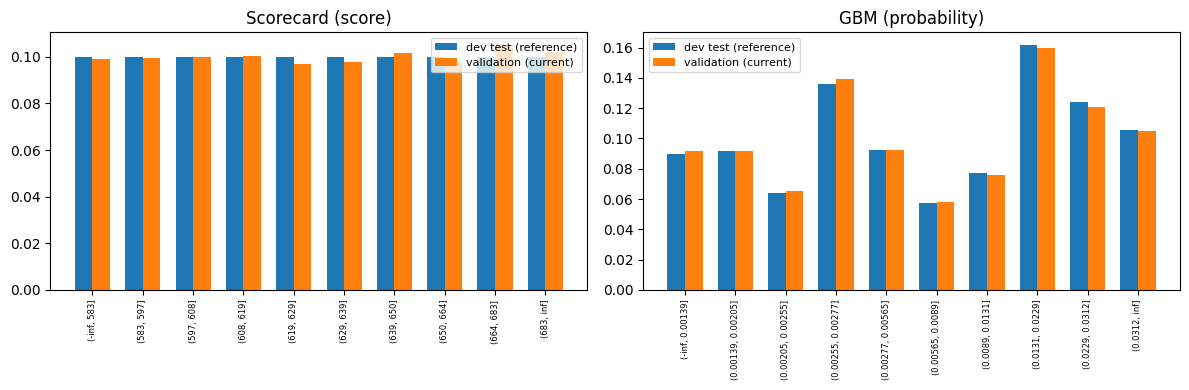

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, tbl) in zip(axes, [('Scorecard (score)', sc_psi_table), ('GBM (probability)', gb_psi_table)]):
    x = np.arange(len(tbl))
    width = 0.35
    ax.bar(x - width/2, tbl['reference_pct'], width, label='dev test (reference)')
    ax.bar(x + width/2, tbl['current_pct'], width, label='validation (current)')
    ax.set_xticks(x)
    ax.set_xticklabels(tbl['bin'], rotation=90, fontsize=6)
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Combined validation scorecard

In [17]:
report = pd.DataFrame([
    {
        'model': 'Scorecard (WoE/IV + LR)',
        'KS': sc_ks, 'KS_pass_(>40%)': sc_ks > 0.40,
        'AUC': sc_auc, 'Gini': 2*sc_auc-1, 'rank_order_monotonic': sc_monotonic,
        'Brier': sc_brier, 'overall_EA_ratio': sc_overall_ea,
        'PSI': sc_psi_value, 'PSI_flag': psi_flag(sc_psi_value),
    },
    {
        'model': 'GBM (SMOTE + LightGBM + Isotonic)',
        'KS': gb_ks, 'KS_pass_(>40%)': gb_ks > 0.40,
        'AUC': gb_auc, 'Gini': 2*gb_auc-1, 'rank_order_monotonic': gb_monotonic,
        'Brier': gb_brier, 'overall_EA_ratio': gb_overall_ea,
        'PSI': gb_psi_value, 'PSI_flag': psi_flag(gb_psi_value),
    },
]).set_index('model')
report.round(4)

,KS,KS_pass_(>40%),AUC,Gini,rank_order_monotonic,Brier,overall_EA_ratio,PSI,PSI_flag
model,,,,,,,,,
Scorecard (WoE/IV + LR),0.4597,True,0.8050,0.6101,True,0.0137,0.9973,0.0006,stable
GBM (SMOTE + LightGBM + Isotonic),0.5296,True,0.8343,0.6686,True,0.0135,0.9884,0.0003,stable


## Summary
- Discrimination (KS): both models clear the 40% KS bar comfortably on held-out test data - Scorecard 46.0%, GBM 53.0% - strong separation between good and bad accounts, not just marginal.
- Rank ordering: both models are checked, not assumed, to be monotonic - decile bad rate strictly rises as the safest-to-riskiest ordering is walked, for both the scorecard's PDO score and the GBM's raw probability. This is what makes either score usable for cutoff-based policy (e.g. "decline below score X") rather than just a ranking that happens to have a high AUC.
- Calibration: Brier scores are low for both (rare-event problem, most predictions correctly near 0), but the Expected/Actual ratio by decile is the sharper diagnostic - it is checked per-decile, not just in aggregate, since a model can have overall E/A near 1.0 while being badly miscalibrated in the tails (exactly where cutoff decisions get made). The scorecard's decile E/A ratios stay in a reasonable 0.83-1.49 band throughout. The GBM's two safest deciles show E/A ratios of 3.4 and 4.8 - not a calibration failure so much as small-sample noise (only 1-2 actual bad accounts in ~3000-row deciles at that end of the distribution), but it matters: isotonic calibration is less trustworthy at the extreme low-risk tail here, worth flagging if the GBM is ever used for very tight approval cutoffs.
- Stability (PSI): the dev-test-vs-validation comparison is the standard "is this population still the same one the model was validated on" check. Both `validation_data_to_be_shared.csv` and `Dev_data_to_be_shared.csv` are described in `instruction.md` as random samples from the same portfolio snapshot, so a low PSI here (0.0006 scorecard, 0.0003 GBM) is an expected sanity check rather than a discovery - a high PSI would have been the red flag worth investigating before any deployment recommendation.
- Reading this table for sign-off: a real MRM review would also want PSI tracked over time (multiple vintages, not one dev-vs-validation snapshot), and characteristic-level (not just score-level) PSI on the top scorecard variables - both are natural extensions once the model is in production and repeat scoring runs are available.